Tokenizing

Create tokens from pretrained model

In [ ]:
from transformers import AutoTokenizer

# Initialize the tokenizer for BigBird
tokenizer = AutoTokenizer.from_pretrained("google/bigbird-roberta-base")

# Tokenize the input string
tokens = tokenizer.tokenize("Hello, my name is Roberto")
print(tokens)

Covert Tokens to IDs

In [3]:
# Convert the tokens into their corresponding vocabulary IDs
input_ids = tokenizer.convert_tokens_to_ids(tokens)
print(input_ids)

[18536, 112, 717, 1539, 419, 32177]


Token get Input IDs 

In [4]:
final_input = tokenizer("Hello, my name is Roberto")
print(final_input)

{'input_ids': [65, 18536, 112, 717, 1539, 419, 32177, 66], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("google/bigbird-roberta-base")

# This single line replaces tokenize(), convert_tokens_to_ids(), and prepare_for_model()
final_input = tokenizer("Hello, my name is Roberto")
print(final_input)

{'input_ids': [65, 18536, 112, 717, 1539, 419, 32177, 66], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


Input IDs

see how these input IDs can be decoded back to text

In [6]:
print(tokenizer.decode(final_input['input_ids']))

[CLS] Hello, my name is Roberto[SEP]


Convert Input IDs to a Tensor

In [7]:
import torch

# Wrap the 1D list of input IDs into a 2D PyTorch tensor (adding a batch dimension)
input_ids_tensor_batched = torch.tensor(final_input['input_ids']).unsqueeze(0)
print(input_ids_tensor_batched)

tensor([[   65, 18536,   112,   717,  1539,   419, 32177,    66]])


In [ ]:
load the model

In [8]:
from transformers import BigBirdModel

# Load the BigBird model architecture with standard global attention
model = BigBirdModel.from_pretrained("google/bigbird-roberta-base", attention_type="original_full")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BigBirdModel LOAD REPORT from: google/bigbird-roberta-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
with torch.no_grad():
    outputs = model(input_ids_tensor_batched)

ExtractLast "Hidden Statess"-> Embeddings

In [10]:
last_hidden_states = outputs.last_hidden_state

print(f"Token: {tokens[0]}\nIndex ID: {input_ids_tensor_batched[0][1]}\nEmbedding: {last_hidden_states[0][0]} \n")

Token: ▁Hello
Index ID: 18536
Embedding: tensor([ 5.6965e-02,  1.6643e-01,  2.1328e-02, -1.3936e-01,  3.5780e-01,
         7.9122e-02, -9.8538e-02,  7.5354e-02,  2.4164e-02, -5.8085e-02,
        -1.2180e-02,  8.9244e-02,  7.7507e-02, -3.5040e-02,  5.5232e-02,
         1.0114e-02,  1.9504e-02,  3.5518e-02,  5.5260e-02, -3.7791e-02,
        -5.1790e-02,  1.0223e-01, -1.1856e-01, -1.5388e-02, -1.1691e-01,
        -4.1252e-02,  8.9849e-02,  8.5703e-02,  2.4591e-02, -5.0291e-03,
        -2.0328e-01, -5.9720e-02,  6.4259e-02, -2.8484e-03,  2.0299e-02,
         1.1066e-01,  1.2673e-01,  2.3043e-02, -1.8443e-01,  6.3116e-02,
         1.9906e-01,  5.0414e-02,  8.4602e-02,  8.6824e-02, -3.6821e-02,
         1.9422e-01,  6.9642e-02,  4.4054e-02, -3.3747e-02, -3.5832e-02,
        -5.9397e-02,  4.8917e-03, -3.5323e-02,  4.6846e-02,  9.2519e-03,
         2.1432e-01, -5.1546e-02,  7.3860e-02,  4.3352e-02, -7.9247e-02,
        -7.4564e-02, -6.1841e-02, -2.5807e-01,  5.3109e-02, -1.7976e-02,
         1

Download Word2vec model

In [11]:
!pip install gensim
import gensim.downloader as api

# Load pre-trained Google News Word2Vec vectors
model = api.load('word2vec-google-news-300')

select words and Extract Embeddings

In [12]:
# List of words to visualize (duplicates removed)
words_list = [
    'dog', 'dogs', 'cat', 'cats', 'man', 'king', 'woman', 'queen', 'dad', 'father',
    'girl', 'son', 'mom', 'mother', 'boy', 'daughter', 'slow', 'slower', 'slowest',
    'fast', 'faster', 'fastest', 'long', 'longer', 'longest', 'short', 'shorter',
    'shortest', 'he', 'himself', 'she', 'herself', 'Rome', 'Italy', 'London',
    'England', 'Paris', 'France', 'rich', 'poor', 'fisherman', 'teacher',
    'actress', 'actor'
]

# Extracting embeddings
embeddings = [model[word] for word in words_list]

2 Dimensional plot

In [13]:
from sklearn.decomposition import PCA

# Applying PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

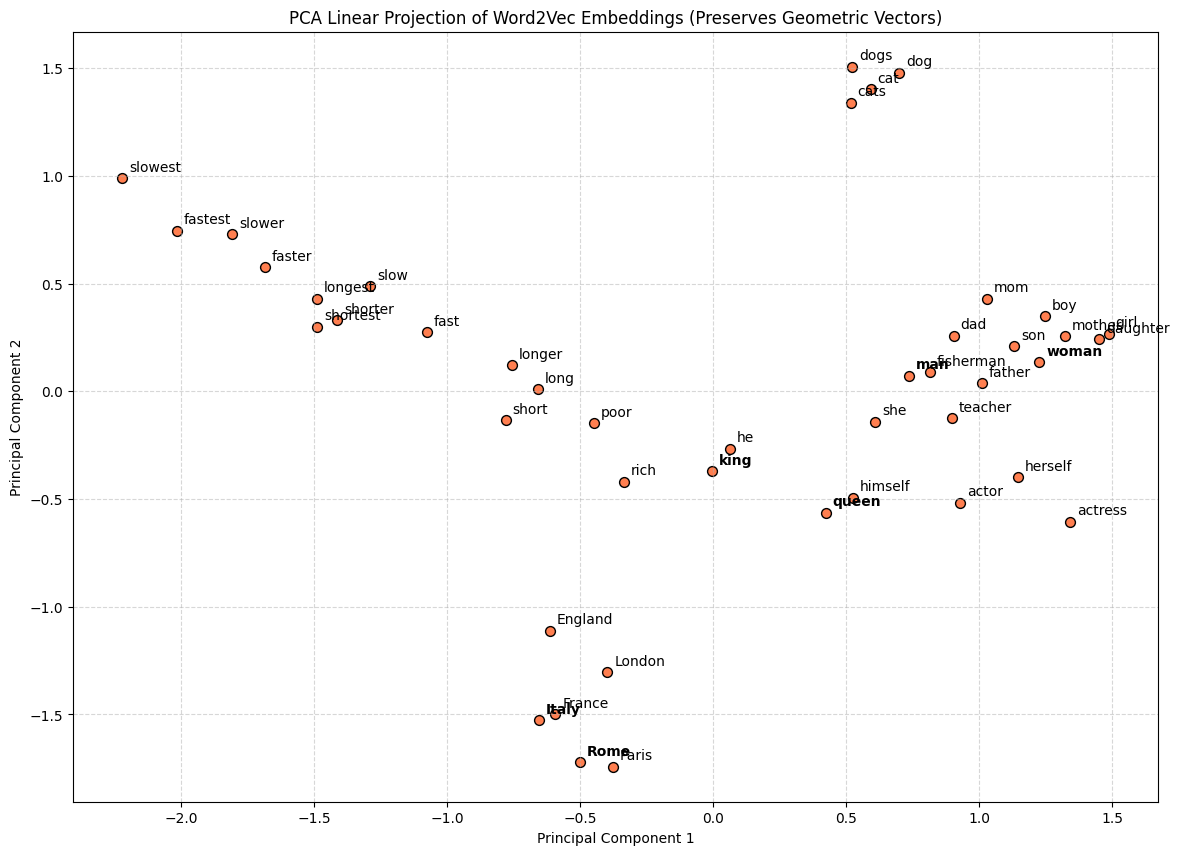

In [14]:
import matplotlib.pyplot as plt

# Set up the plot size
plt.figure(figsize=(14, 10))

# Scatter plot the 2D coordinates
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], edgecolors='k', c='coral', s=50)

# Loop through and annotate each point with its word string
for i, word in enumerate(words_list):
    plt.annotate(
        word,
        xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=10,
        weight='bold' if word in ['king', 'queen', 'man', 'woman', 'Rome', 'Italy'] else 'normal'
    )

plt.title("PCA Linear Projection of Word2Vec Embeddings (Preserves Geometric Vectors)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Visualize word embeddings

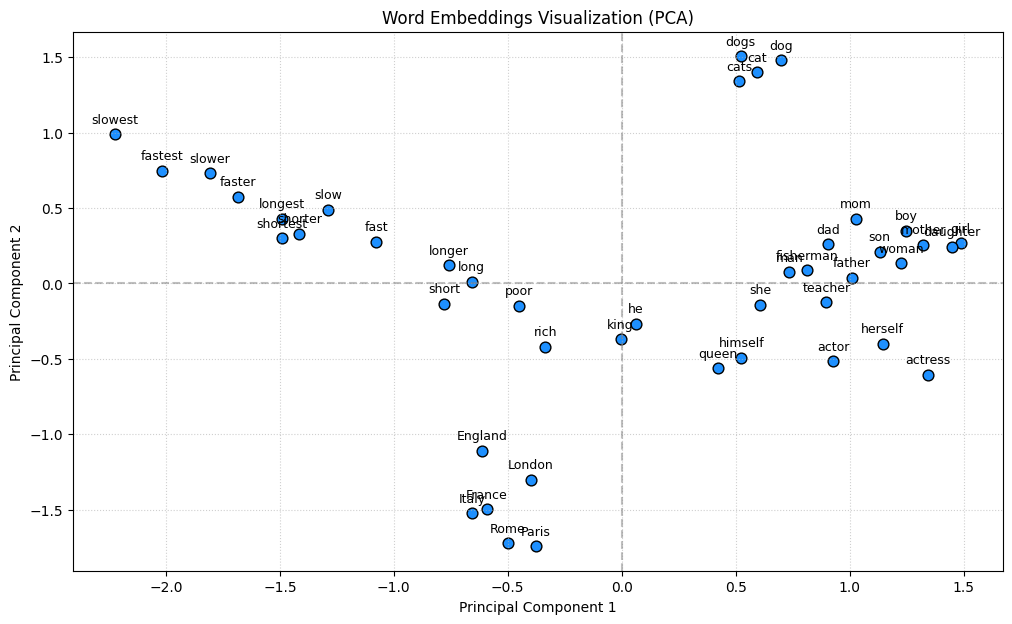

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Draw the axis lines across the origin
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 1. Plot ALL points at once (much more efficient)
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='dodgerblue', edgecolors='k', s=60)

# 2. Use the loop strictly for annotations
for i, word in enumerate(words_list):
    plt.annotate(
        word,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9
    )

plt.title('Word Embeddings Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Instal langchain packages

In [16]:
!pip install langchain langchain-community gpt4all

In [17]:
import os
from pathlib import Path

# Check the default GPT4All cache directory
cache_path = Path.home() / ".cache" / "gpt4all"

if cache_path.exists():
    print(f"Directory found: {cache_path}")
    print("Files inside:", os.listdir(cache_path))
else:
    print("The default cache directory does not exist yet. Ensure you have run llm.invoke() successfully.")

The default cache directory does not exist yet. Ensure you have run llm.invoke() successfully.


In [18]:
import os
from gpt4all import GPT4All
from pathlib import Path

# Define the exact directory path
cache_dir = Path.home() / ".cache" / "gpt4all"
os.makedirs(cache_dir, exist_ok=True)

print("Starting download... This may take a minute on Kaggle's network.")

# This forces the download into the correct folder
GPT4All.download_model('orca-mini-3b-gguf2-q4_0.gguf', cache_dir)

print("\nSuccess! Files now inside cache:", os.listdir(cache_dir))

Starting download... This may take a minute on Kaggle's network.


Downloading: 100%|██████████| 1.98G/1.98G [00:35<00:00, 56.0MiB/s]


Success! Files now inside cache: ['orca-mini-3b-gguf2-q4_0.gguf']



Model downloaded to '/root/.cache/gpt4all/orca-mini-3b-gguf2-q4_0.gguf'


Ask question to an LLM

In [19]:
from langchain_community.llms import GPT4All

# Since it's in the default cache directory, we just need the filename
llm = GPT4All(model='orca-mini-3b-gguf2-q4_0.gguf')

# Define Prompt (stray parenthesis removed)
prompt = "Where is Peru?"

# Pass prompt to LLM to generate text using the updated invoke method
response = llm.invoke(prompt)

print(response)

/tmp/ipykernel_7126/364595817.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.llms import GPT4All



Peru is located in the western coast of South America, bordering Ecuador, Colombia, Brazil, Bolivia and Chile. It has a diverse geography that ranges from the Andes Mountains to the Pacific Ocean. The capital city of Peru is Lima, which is also its largest city.


In [20]:
from langchain_community.llms import GPT4All

# Initialize Model referencing your successfully downloaded file name
llm = GPT4All(model='orca-mini-3b-gguf2-q4_0.gguf')

# Define the classification prompt
prompt = """
Classify the email subject text below, delimited by three dashes (-),
as being malicious or benign. Explain why.

---
Account email verification code, enter now and reply
---
"""

# Pass prompt to LLM to generate text using the updated invoke method
response = llm.invoke(prompt)

print(response)


This is a benign email subject text as it is asking for an account verification code to ensure that the user is indeed the intended recipient of the email. The email does not contain any malicious content or actions that would harm the user's system or data.
